In [57]:
#Step1 - Import Necessarry Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
#Step2 - Read Dataset
df = pd.read_csv("student_depression_dataset.csv")

In [59]:
#first rows of the dataset
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0


In [60]:
#tail
#Bottom rows
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27,Surat,Student,5,0,5.75,5,0,'5-6 hours',Unhealthy,'Class 12',Yes,7,1,Yes,0
27897,140686,Male,27,Ludhiana,Student,2,0,9.40,3,0,'Less than 5 hours',Healthy,MSc,No,0,3,Yes,0
27898,140689,Male,31,Faridabad,Student,3,0,6.61,4,0,'5-6 hours',Unhealthy,MD,No,12,2,No,0
27899,140690,Female,18,Ludhiana,Student,5,0,6.88,2,0,'Less than 5 hours',Healthy,'Class 12',Yes,10,5,No,1
27900,140699,Male,27,Patna,Student,4,0,9.24,1,0,'Less than 5 hours',Healthy,BCA,Yes,2,3,Yes,1


In [61]:
#Step3 - Sanity check of Data
#Shape
df.shape # rows & columns

(27901, 18)

In [62]:
df.info()  #All information about Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  int64  
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [63]:
#Drop unnecessary columns
df = df.drop(columns=['id', 'Profession', 'Work Pressure', 'Job Satisfaction'])
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,Visakhapatnam,5,8.97,2,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,Female,24,Bangalore,2,5.90,5,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,Male,31,Srinagar,3,7.03,5,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,Female,28,Varanasi,3,5.59,2,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,Female,25,Jaipur,4,8.13,3,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0


In [64]:
#Rename necessary columns
df = df.rename(columns={'Work/Study Hours':'Study Hours'})
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,Visakhapatnam,5,8.97,2,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,Female,24,Bangalore,2,5.90,5,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,Male,31,Srinagar,3,7.03,5,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,Female,28,Varanasi,3,5.59,2,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,Female,25,Jaipur,4,8.13,3,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0


In [65]:
#Checking missing values
df.isnull().sum()

,0
Gender,0
Age,0
City,0
Academic Pressure,0
CGPA,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Degree,0
Have you ever had suicidal thoughts ?,0


In [66]:
#Finding Duplicates
df.duplicated().sum()

np.int64(0)

In [67]:
#Finding garbage values
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("***"*10)

Gender
Male      15547
Female    12354
Name: count, dtype: int64
******************************
City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                   699
Vadodara                 694
Varanasi                 685
Nagpur                   651
Indore                   643
Kanpur                   609
Nashik                   547
Faridabad                461
Saanvi                     2


In [68]:
#Step4 - Exploratory Data Analysis (EDA)
#Discriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


In [69]:
#Descriptive Statistics from object columns
df.describe(include="object")

,Gender,City,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Financial Stress,Family History of Mental Illness
count,27901,27901,27901,27901,27901,27901,27901,27901
unique,2,52,5,4,28,2,6,2
top,Male,Kalyan,'Less than 5 hours',Unhealthy,'Class 12',Yes,5,No
freq,15547,1570,8310,10317,6080,17656,6715,14398


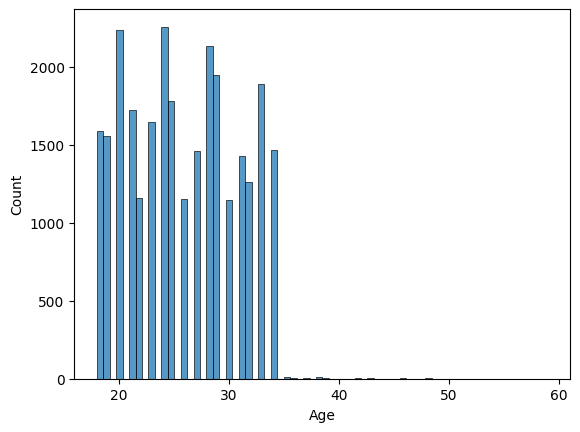

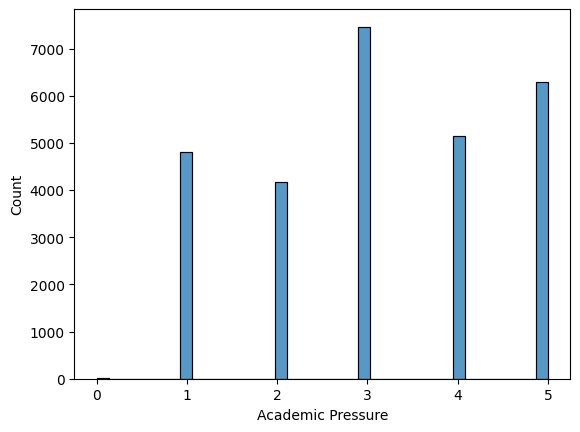

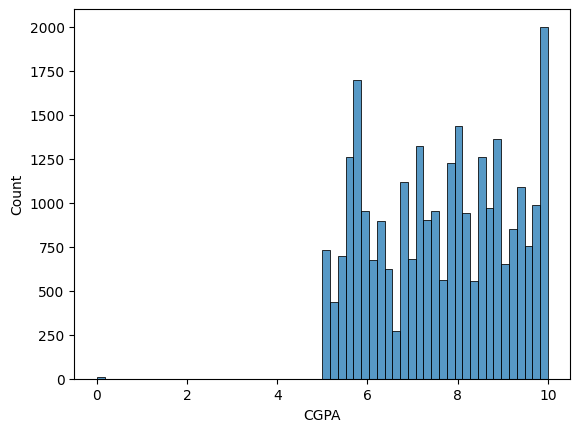

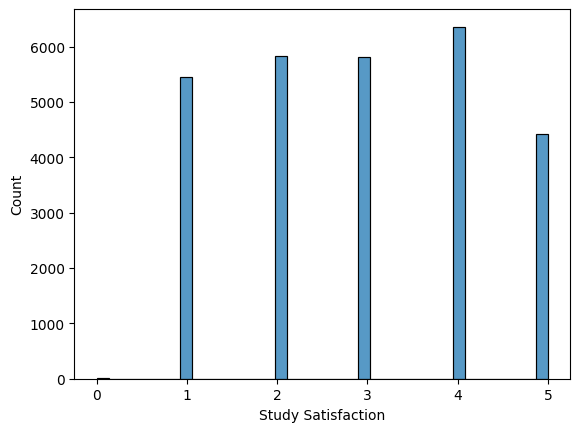

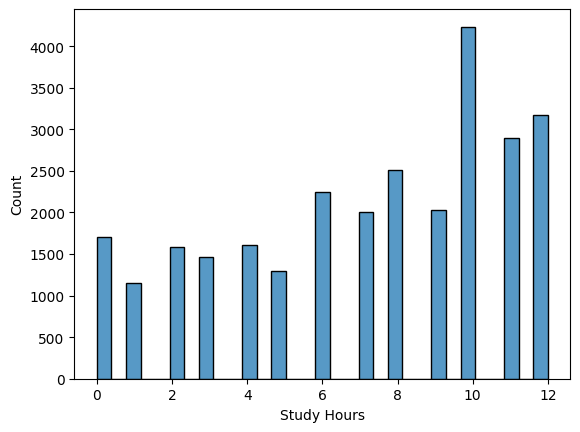

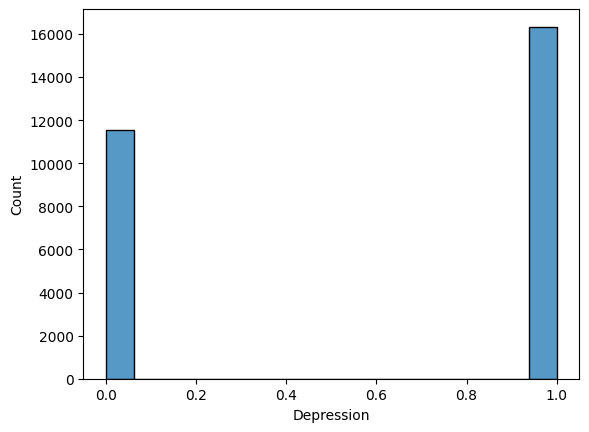

In [70]:
#histogram to understand the distribution
import warnings
warnings.filterwarnings("ignore")
for i  in df.select_dtypes(include="number").columns:
    sns.histplot(data=df,x=i)
    plt.show()

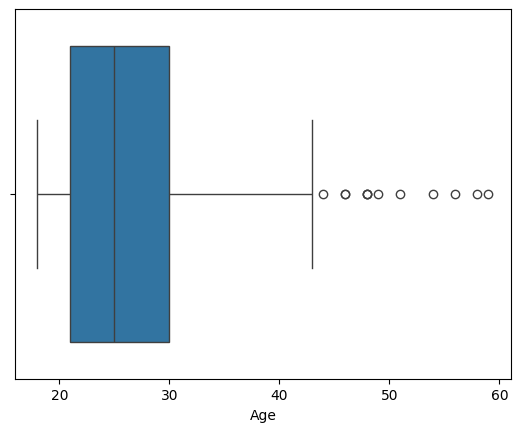

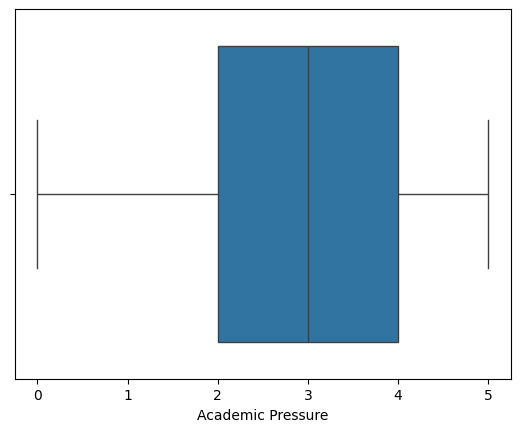

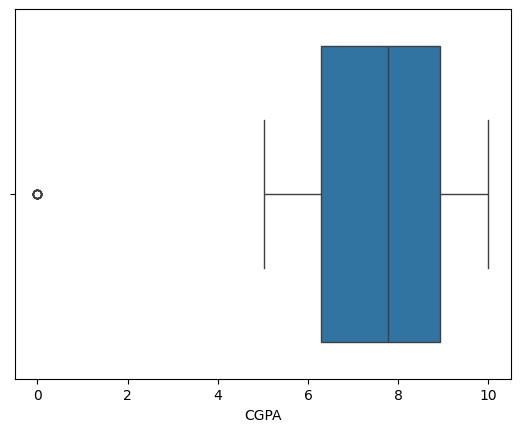

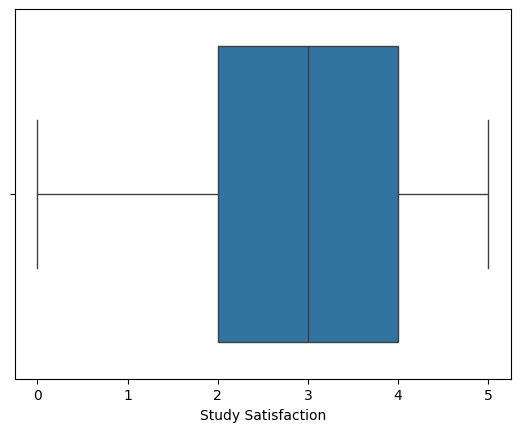

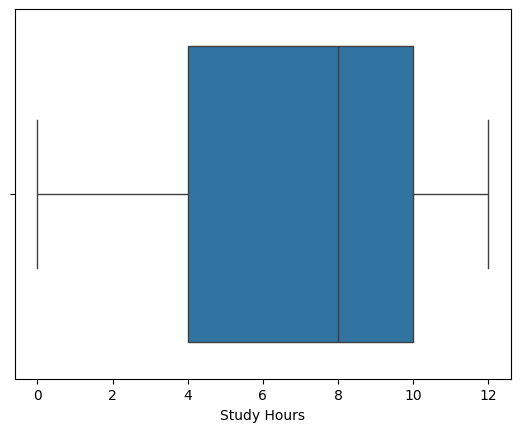

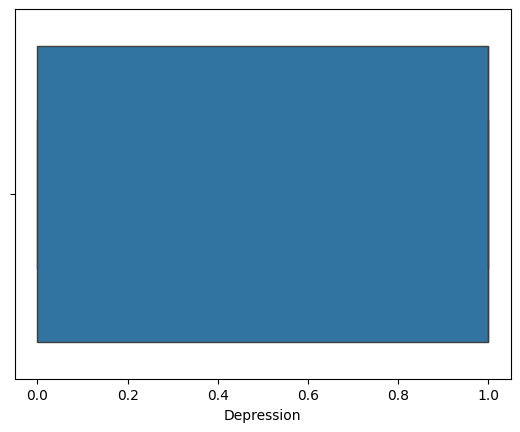

In [71]:
#Boxplot to understand Outliers
import warnings
warnings.filterwarnings("ignore")
for i  in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()

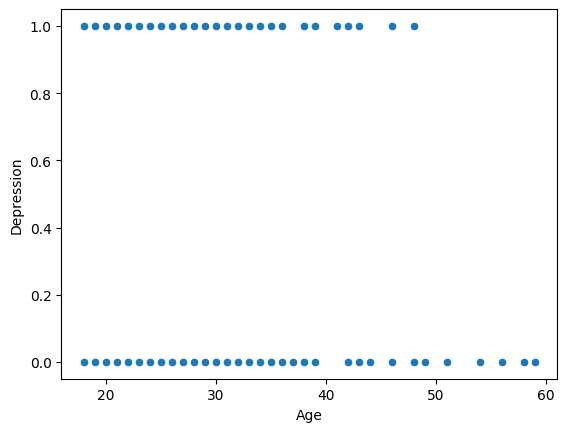

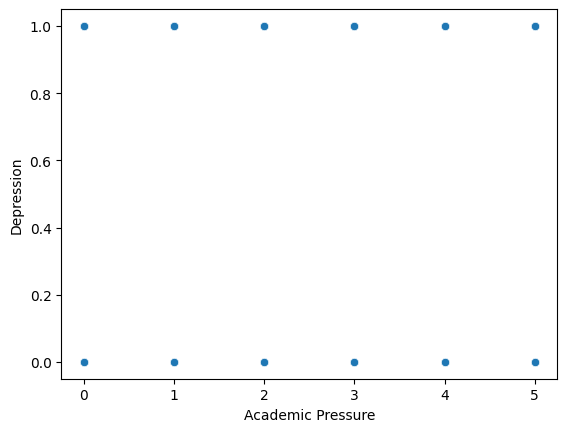

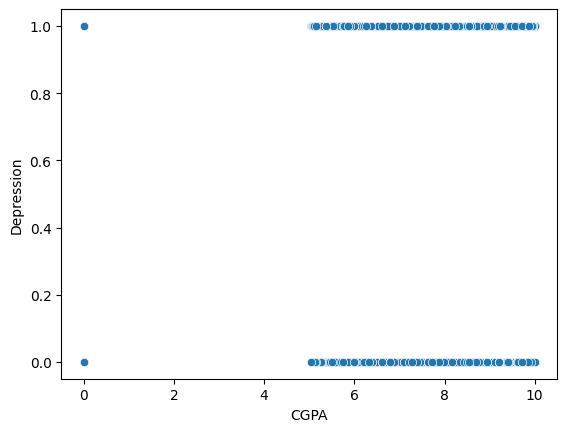

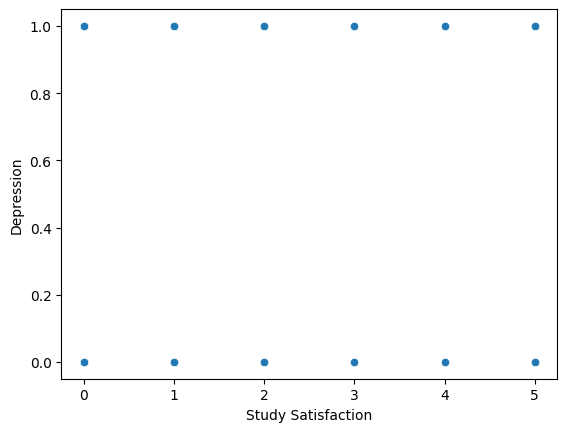

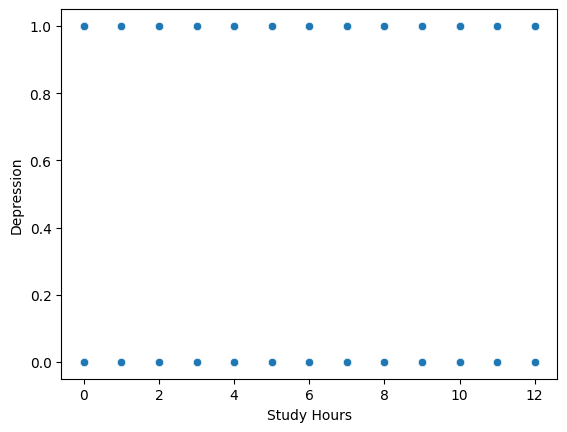

In [72]:
#Scatter plot to understand the relationship between the target and dependent variables
for i in ['Age', 'Academic Pressure', 'CGPA','Study Satisfaction', 'Study Hours']:
    sns.scatterplot(data=df,x=i,y='Depression')
    plt.show()

In [73]:
df.select_dtypes(include="number").columns

Index(['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Study Hours',
       'Depression'],
      dtype='object')

In [74]:
#Correlation with heatmap to interpret the relation and multicolliniarity
c = df.select_dtypes(include="number").corr()


<Axes: >

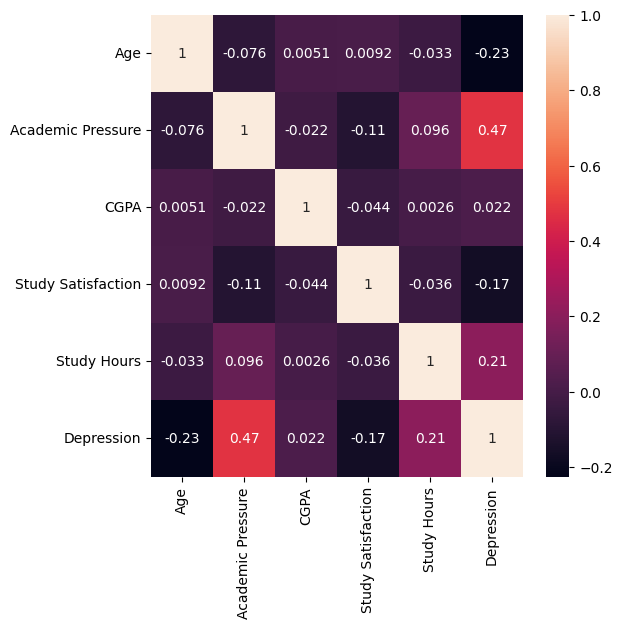

In [75]:
#Use Heatmap to show the Correlation
plt.figure(figsize=(6,6))
sns.heatmap(c,annot=True)
#annot for add values

In [76]:
#Step 5: Missing Value tretaments
df.isnull().sum()
#There are no any rows with missing values

,0
Gender,0
Age,0
City,0
Academic Pressure,0
CGPA,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Degree,0
Have you ever had suicidal thoughts ?,0


In [77]:
#Step 6: Outliers treatments
#creating a function to identify lower & uper wiskers
def wisker(col):
    q1,q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5*iqr
    uw = q3 + 1.5*iqr
    return lw,uw

In [78]:
#check the function
wisker(df['Age'])

(np.float64(7.5), np.float64(43.5))

In [79]:
#remove the outliers for selected features
for i in ['CGPA', 'Age']:
    lw, uw = wisker(df[i])
    df[i] = np.where(df[i]<lw,lw,df[i])
    df[i] = np.where(df[i]>uw,uw,df[i])


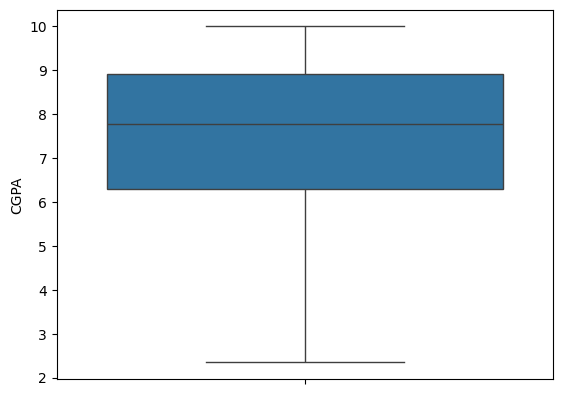

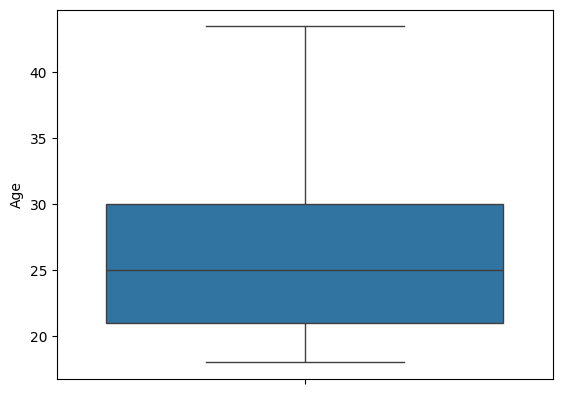

In [80]:
#Check outliers removal
for i in ['CGPA', 'Age']:
    sns.boxplot(df[i])
    plt.show()

In [81]:
#Step 7: Duplicates & Garbage value treatments

# To check for duplicate rows
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

# check columns which have duplicate values
duplicate_columns = df.columns[df.columns.duplicated()].tolist()
print(f"Duplicate columns: {duplicate_columns}")


Number of duplicate rows: 0
Duplicate columns: []


In [82]:
#Step 8: Encoding of data
df.head(10)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,5,8.97,2,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,Female,24.0,Bangalore,2,5.90,5,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,Male,31.0,Srinagar,3,7.03,5,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,Female,28.0,Varanasi,3,5.59,2,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,Female,25.0,Jaipur,4,8.13,3,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0
5,Male,29.0,Pune,2,5.70,3,'Less than 5 hours',Healthy,PhD,No,4,1,No,0
6,Male,30.0,Thane,3,9.54,4,'7-8 hours',Healthy,BSc,No,1,2,No,0
7,Female,30.0,Chennai,2,8.04,4,'Less than 5 hours',Unhealthy,'Class 12',No,0,1,Yes,0
8,Male,28.0,Nagpur,3,9.79,1,'7-8 hours',Moderate,B.Ed,Yes,12,3,No,1
9,Male,31.0,Nashik,2,8.38,3,'Less than 5 hours',Moderate,LLB,Yes,2,5,No,1


In [83]:
# Gender -> label encoding
# City -> Target encoding
# Sleep duration -> Ordinal Encoding
# Dietary habits ->  Ordinal Encoding
# Degree -> Target Encoding
# Have you ever had suicidal thoughts ? -> label encoding
# Family History of Mental Illness -> label encoding

In [84]:
# Identify all possible unique values for each column to encode

categorical_columns = [
    'Gender',
    'City',
    'Sleep Duration',
    'Dietary Habits',
    'Degree',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]


In [85]:
# Print unique values for each categorical column
for col in categorical_columns:
    uniques = df[col].unique()
    print(f"Unique values in '{col}': {uniques}")
    print('----------------------------------------------------------------------------------------')

Unique values in 'Gender': ['Male' 'Female']
----------------------------------------------------------------------------------------
Unique values in 'City': ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' "'Less Delhi'" 'City' '3'
 "'Less than 5 Kalyan'" 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh'
 'Reyansh' 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini'
 'Nandini' 'Khaziabad']
----------------------------------------------------------------------------------------
Unique values in 'Sleep Duration': ["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"
 'Others']
----------------------------------------------------------------------------------------
Unique values in 'Dietary Hab

In [86]:
df.columns

Index(['Gender', 'Age', 'City', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [87]:
# Create a copy of df for encoding
df_encode = df.copy()


In [88]:
df_encode.head()


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,5,8.97,2,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,Female,24.0,Bangalore,2,5.90,5,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,Male,31.0,Srinagar,3,7.03,5,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,Female,28.0,Varanasi,3,5.59,2,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,Female,25.0,Jaipur,4,8.13,3,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0


#Fix NaN Introduction and Re-clean

In [89]:
# Check for non-numeric or NaN values in Financial Stress
print("Unique values in Financial Stress:\n", df_encode['Financial Stress'].unique())
print("\nNaNs in Financial Stress:", df_encode['Financial Stress'].isnull().sum())

# Convert Financial Stress to numeric, coercing errors to NaN
df_encode['Financial Stress'] = pd.to_numeric(df_encode['Financial Stress'], errors='coerce')

# Drop rows with NaN in Financial Stress
df_encode = df_encode.dropna(subset=['Financial Stress'])

# Verify the clean
print("\ndf_encode shape after cleaning Financial Stress:", df_encode.shape)
print("\nNaNs in df_encode after cleaning:\n", df_encode.isnull().sum())

Unique values in Financial Stress:
 ['1' '2' '5' '3' '4' '?']

NaNs in Financial Stress: 0

df_encode shape after cleaning Financial Stress: (27898, 14)

NaNs in df_encode after cleaning:
 Gender                                   0
Age                                      0
City                                     0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [90]:
# Encode the columns
# Label Encoding for Gender
gender_map = {'Male':0,'Female':1}
df_encode['Gender'] = df['Gender'].map(gender_map)

# Target Encoding for City
city_means = df.groupby('City')['Depression'].mean()
df_encode['City'] = df['City'].map(city_means)

# Ordinal Encoding for Sleep Duration
sleep_map = {"'5-6 hours'":2, "'Less than 5 hours'":1, "'7-8 hours'":3, "'More than 8 hours'":4, 'Others':0}
df_encode['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)

# Ordinal Encoding for Dietary Habits
diet_map = {'Healthy':3, 'Moderate':2, 'Unhealthy':1, 'Others':0}
df_encode['Dietary Habits'] = df['Dietary Habits'].map(diet_map)

# Target Encoding for Degree
degree_means = df.groupby('Degree')['Depression'].mean()
df_encode['Degree'] = df['Degree'].map(degree_means)

# Label Encoding for 'Have you ever had suicidal thoughts ?'
suicidal_map = {'Yes':1, 'No':0}
df_encode['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map(suicidal_map)

# Label Encoding for 'Family History of Mental Illness'
family_map = {'No':0, 'Yes':1}
df_encode['Family History of Mental Illness'] = df['Family History of Mental Illness'].map(family_map)



In [91]:
#check encoding
df_encode.head(10)

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,33.0,0.569659,5,8.97,2,2,3,0.528395,1,3,1.0,0,1
1,1,24.0,0.608866,2,5.90,5,2,2,0.588964,0,3,2.0,1,0
2,0,31.0,0.556122,3,7.03,5,1,3,0.535000,0,9,1.0,1,0
3,1,28.0,0.531387,3,5.59,2,3,2,0.571528,1,4,5.0,1,1
4,1,25.0,0.524131,4,8.13,3,2,2,0.509785,1,1,1.0,0,0
5,0,29.0,0.558884,2,5.70,3,1,3,0.547893,0,4,1.0,0,0
6,0,30.0,0.590869,3,9.54,4,3,3,0.588964,0,1,2.0,0,0
7,1,30.0,0.596610,2,8.04,4,1,1,0.707730,0,0,1.0,1,0
8,0,28.0,0.557604,3,9.79,1,3,2,0.546867,1,12,3.0,0,1
9,0,31.0,0.528336,2,8.38,3,1,2,0.530551,1,2,5.0,0,1


In [92]:
df_encode.describe()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000
mean,0.442756,25.819127,0.585497,3.141336,7.656917,2.943974,2.397484,1.903541,0.585501,0.632877,7.156570,3.139867,0.483942,0.585526
std,0.496721,4.891446,0.040430,1.381462,1.467369,1.361122,1.127994,0.797742,0.067989,0.482029,3.707598,1.437347,0.499751,0.492640
min,0.000000,18.000000,0.000000,0.000000,2.345000,0.000000,0.000000,0.000000,0.505481,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,21.000000,0.556122,2.000000,6.290000,2.000000,1.000000,1.000000,0.535441,0.000000,4.000000,2.000000,0.000000,0.000000
50%,0.000000,25.000000,0.582358,3.000000,7.770000,3.000000,2.000000,2.000000,0.566401,1.000000,8.000000,3.000000,0.000000,1.000000
75%,1.000000,30.000000,0.608818,4.000000,8.920000,4.000000,3.000000,3.000000,0.589310,1.000000,10.000000,4.000000,1.000000,1.000000
max,1.000000,43.500000,1.000000,5.000000,10.000000,5.000000,4.000000,3.000000,0.707730,1.000000,12.000000,5.000000,1.000000,1.000000


<Axes: >

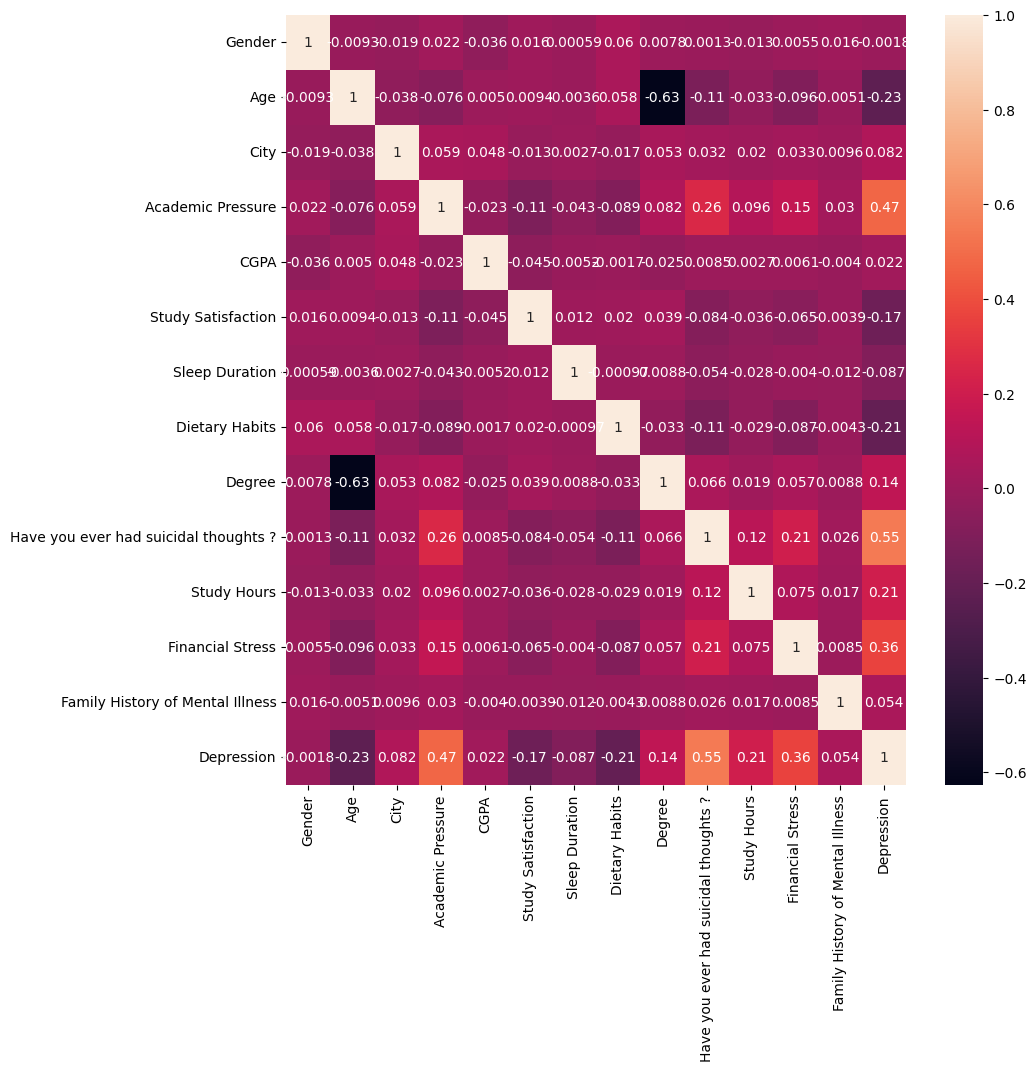

In [93]:
c_encode = df_encode.select_dtypes(include='number').corr()
plt.figure(figsize=(10,10))
sns.heatmap(c_encode, annot=True )

In [94]:
df_encode.describe()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000
mean,0.442756,25.819127,0.585497,3.141336,7.656917,2.943974,2.397484,1.903541,0.585501,0.632877,7.156570,3.139867,0.483942,0.585526
std,0.496721,4.891446,0.040430,1.381462,1.467369,1.361122,1.127994,0.797742,0.067989,0.482029,3.707598,1.437347,0.499751,0.492640
min,0.000000,18.000000,0.000000,0.000000,2.345000,0.000000,0.000000,0.000000,0.505481,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,21.000000,0.556122,2.000000,6.290000,2.000000,1.000000,1.000000,0.535441,0.000000,4.000000,2.000000,0.000000,0.000000
50%,0.000000,25.000000,0.582358,3.000000,7.770000,3.000000,2.000000,2.000000,0.566401,1.000000,8.000000,3.000000,0.000000,1.000000
75%,1.000000,30.000000,0.608818,4.000000,8.920000,4.000000,3.000000,3.000000,0.589310,1.000000,10.000000,4.000000,1.000000,1.000000
max,1.000000,43.500000,1.000000,5.000000,10.000000,5.000000,4.000000,3.000000,0.707730,1.000000,12.000000,5.000000,1.000000,1.000000


In [95]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_encode.drop('Depression', axis=1)  # All columns except target
y = df_encode['Depression']


# Convert all columns to numeric type
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Apply StandardScaler to features only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for ease
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Check the result
X_scaled_df.describe()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness
count,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04,2.789800e+04
mean,4.508067e-17,7.946424e-17,-1.039148e-15,-7.870016e-17,9.683431e-16,-1.469579e-16,4.533537e-17,1.339686e-16,-6.415719e-16,-1.016225e-16,-1.134658e-16,-4.941046e-17,5.093861e-19
std,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00
min,-8.913727e-01,-1.598560e+00,-1.448207e+01,-2.273962e+00,-3.620092e+00,-2.162942e+00,-2.125479e+00,-2.386205e+00,-1.176976e+00,-1.312967e+00,-1.930279e+00,-1.488788e+00,-9.683826e-01
25%,-8.913727e-01,-9.852329e-01,-7.265655e-01,-8.261945e-01,-9.315590e-01,-6.935394e-01,-1.238933e+00,-1.132644e+00,-7.363143e-01,-1.312967e+00,-8.513940e-01,-7.930495e-01,-9.683826e-01
50%,-8.913727e-01,-1.674641e-01,-7.763194e-02,-1.023110e-01,7.706682e-02,4.116203e-02,-3.523874e-01,1.209166e-01,-2.809300e-01,7.616338e-01,2.274909e-01,-9.731067e-02,-9.683826e-01
75%,1.121865e+00,8.547469e-01,5.768419e-01,6.215725e-01,8.607963e-01,7.758634e-01,5.341582e-01,1.374477e+00,5.602623e-02,7.616338e-01,7.669333e-01,5.984282e-01,1.032650e+00
max,1.121865e+00,3.614717e+00,1.025260e+01,1.345456e+00,1.596821e+00,1.510565e+00,1.420704e+00,1.374477e+00,1.797822e+00,7.616338e-01,1.306376e+00,1.294167e+00,1.032650e+00


In [96]:
df_encode.isnull().sum()

,0
Gender,0
Age,0
City,0
Academic Pressure,0
CGPA,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Degree,0
Have you ever had suicidal thoughts ?,0


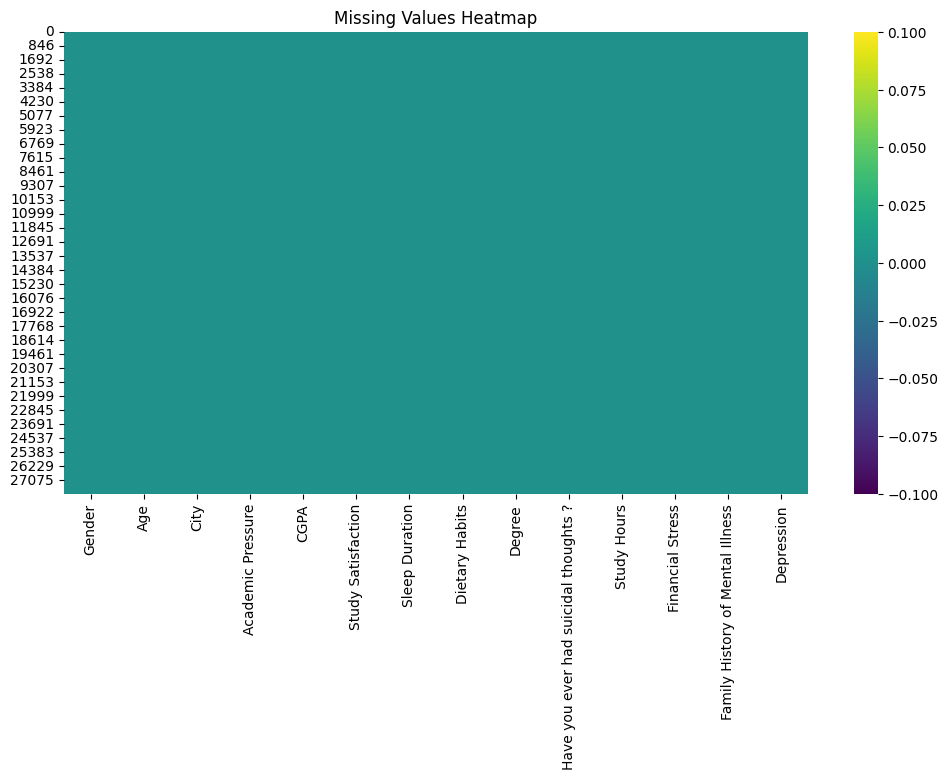

In [97]:
#check again missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_encode.isnull(), cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [98]:
#Check the class Imbalance
df_encode['Depression'].value_counts(normalize=True)

,proportion
Depression,
1,0.585526
0,0.414474


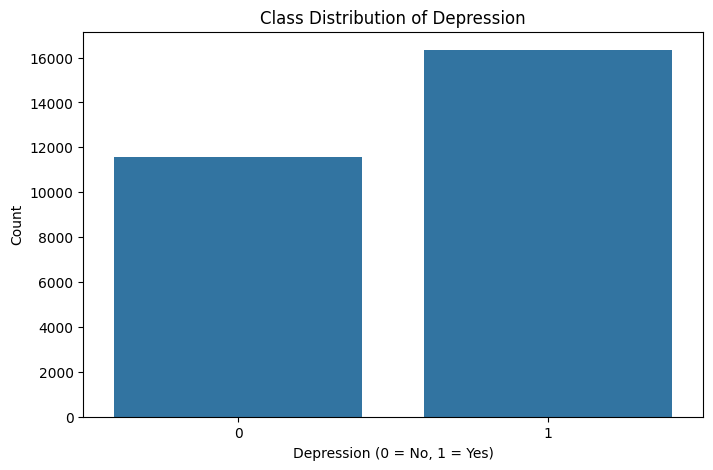

In [99]:
#Check the class Imbalance graphically
plt.figure(figsize=(8, 5))
sns.countplot(x='Depression', data=df_encode)
plt.title('Class Distribution of Depression')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

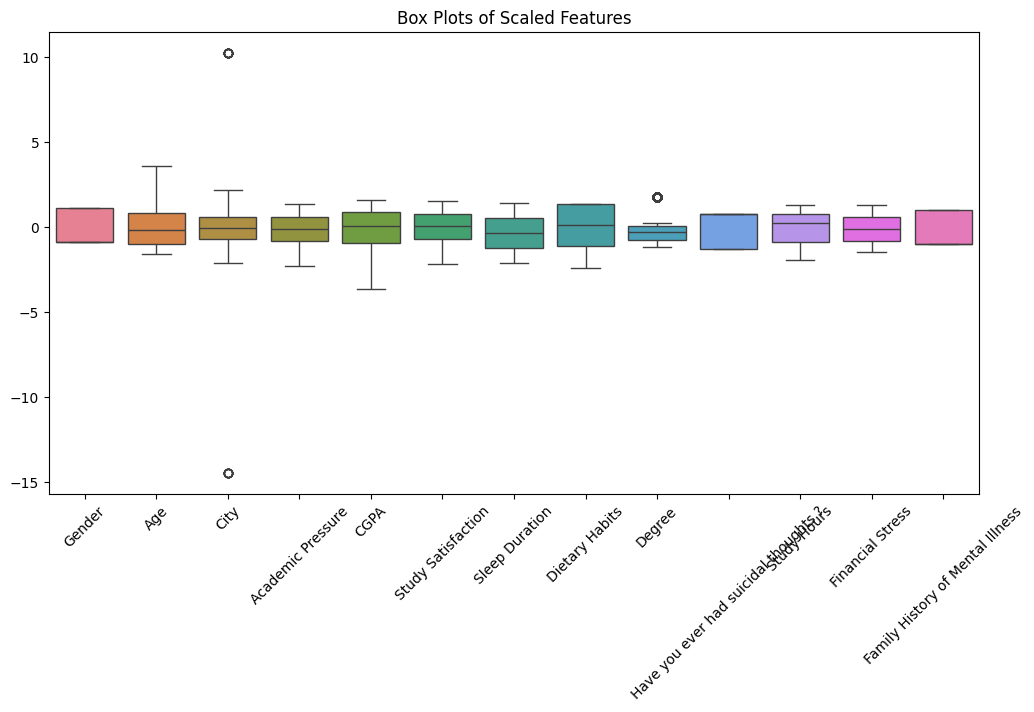

In [100]:
#check Feature Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_scaled_df)
plt.title('Box Plots of Scaled Features')
plt.xticks(rotation=45)
plt.show()

#Split the Data into Training and Testing Sets

In [101]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80/20 split, stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

# Check the shape to confirm split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Verify class distribution in training set (should reflect original imbalance)
print("\ny_train distribution:\n", y_train.value_counts(normalize=True))

X_train shape: (22318, 13)
X_test shape: (5580, 13)
y_train shape: (22318,)
y_test shape: (5580,)

y_train distribution:
 Depression
1    0.585536
0    0.414464
Name: proportion, dtype: float64


# Apply SMOTE to Balance the Training Data

In [102]:
from imblearn.over_sampling import SMOTE
from google.colab import files

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Balanced y_train distribution:\n", y_train_balanced.value_counts(normalize=True))

# Combine features and target into one DataFrame
balanced_df = pd.DataFrame(X_train_balanced, columns=X_train.columns)
balanced_df['target'] = y_train_balanced

# Save to CSV file
balanced_df.to_csv('balanced_dataset.csv', index=False)

# Download the file to your computer
files.download('balanced_dataset.csv')

Balanced y_train distribution:
 Depression
1    0.5
0    0.5
Name: proportion, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Proceed with Model Training

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_balanced, y_train_balanced)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.842831541218638

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81      2313
           1       0.88      0.85      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580



#Evaluate with Cross-Validation

In [104]:
from sklearn.model_selection import cross_val_score

# Initialize the model
model = LogisticRegression(random_state=42, max_iter=1000)

# Perform 5-fold cross-validation on the balanced training data
cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')

# Print the results
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.84506503 0.84216568 0.84312225 0.84522671 0.84905299]
Mean CV accuracy: 0.84492653280909
Standard deviation: 0.002367054082951244


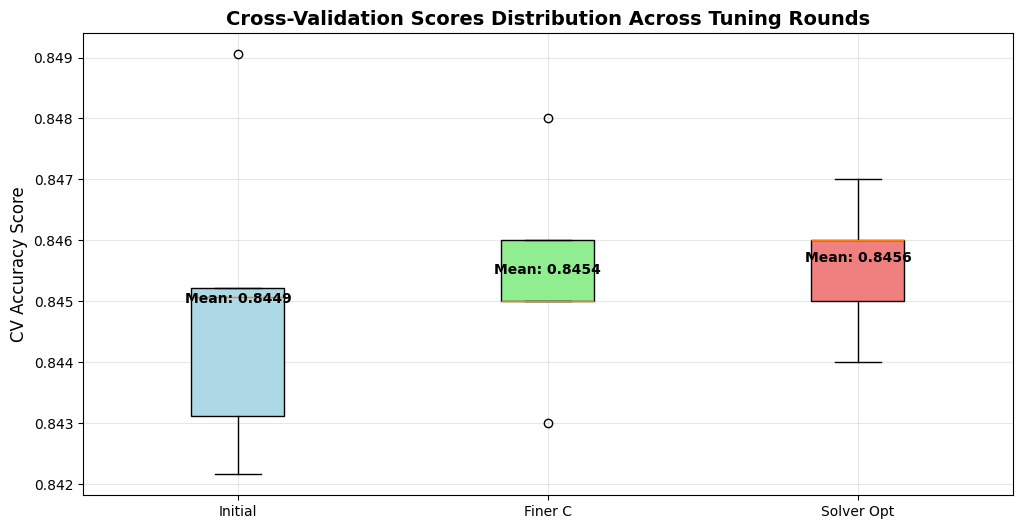

In [105]:
# =============================================================================
# VISUALIZATION 2: Cross-Validation Scores Comparison
# =============================================================================

# CV scores from different tuning rounds (you'll need to capture these)
cv_scores = {
    'Initial': [0.84506503, 0.84216568, 0.84312225, 0.84522671, 0.84905299],
    'Finer C': [0.845, 0.843, 0.846, 0.845, 0.848],  # Replace with actual if available
    'Solver Opt': [0.846, 0.844, 0.847, 0.845, 0.846]  # Replace with actual
}

plt.figure(figsize=(12, 6))

# Box plot for CV scores distribution
boxes = plt.boxplot(cv_scores.values(), labels=cv_scores.keys(), patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(boxes['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Cross-Validation Scores Distribution Across Tuning Rounds', fontsize=14, fontweight='bold')
plt.ylabel('CV Accuracy Score', fontsize=12)
plt.grid(True, alpha=0.3)

# Add mean values on the plot
means = [np.mean(scores) for scores in cv_scores.values()]
for i, mean in enumerate(means):
    plt.text(i+1, mean, f'Mean: {mean:.4f}', ha='center', va='bottom', fontweight='bold')

plt.show()

#Hyperparameter Tuning with Grid Search

In [106]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],               # Type of regularization
    'solver': ['liblinear']                # Solver for small datasets, supports l1/l2
}

# Initialize the model
model = LogisticRegression(random_state=42, max_iter=1000)

# Perform Grid Search with 5-fold CV
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_balanced, y_train_balanced)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate on test set with best model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print("Tuned Accuracy:", accuracy_tuned)
print("\nTuned Classification Report:\n", classification_report(y_test, y_pred_tuned))

Best parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.8450412921314188
Tuned Accuracy: 0.8415770609318997

Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81      2313
           1       0.88      0.85      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580



In [107]:
# Second Round of Hyperparameter Tuning - Finer C-values
print("\n=== Second Tuning: Finer C-value Exploration ===")

param_grid_finer = {
    'C': [0.0001, 0.0005, 0.001, 0.005, 0.01],  # Finer granularity around 0.001
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Perform Grid search with 5-fold CV
grid_search_finer = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                                param_grid_finer, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_finer.fit(X_train_balanced, y_train_balanced)

# Print the best parameters and score
print("Best parameters (finer tuning):", grid_search_finer.best_params_)
print("Best cross-validation score (finer):", grid_search_finer.best_score_)

# Evaluate on test set with best model from finer tuning
best_model_finer = grid_search_finer.best_estimator_
y_pred_finer = best_model_finer.predict(X_test)
accuracy_finer = accuracy_score(y_test, y_pred_finer)
print("Finer Tuned Accuracy:", accuracy_finer)
print("\nFiner Tuned Classification Report:\n", classification_report(y_test, y_pred_finer))

# Compare with previous best
print("Accuracy Improvement:", accuracy_finer - accuracy_tuned)


=== Second Tuning: Finer C-value Exploration ===
Best parameters (finer tuning): {'C': 0.0005, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score (finer): 0.8454239281091397
Finer Tuned Accuracy: 0.8417562724014337

Finer Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81      2313
           1       0.88      0.84      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580

Accuracy Improvement: 0.00017921146953403522


In [108]:
# Third Round of Hyperparameter Tuning - Different Solvers
print("\n=== Third Tuning: Different Solvers ===")

param_grid_solvers = {
    'C': [0.0005, 0.001, 0.01],  # Using our best C values
    'penalty': ['l2', 'none'],
    'solver': ['lbfgs', 'newton-cg', 'saga']
}

# Perform Grid search with 5-fold CV
grid_search_solvers = GridSearchCV(LogisticRegression(random_state=42, max_iter=2000),
                                  param_grid_solvers, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_solvers.fit(X_train_balanced, y_train_balanced)

# Print the best parameters and score
print("Best parameters (solver tuning):", grid_search_solvers.best_params_)
print("Best cross-validation score (solver):", grid_search_solvers.best_score_)

# Evaluate on test set with best model from solver tuning
best_model_solvers = grid_search_solvers.best_estimator_
y_pred_solvers = best_model_solvers.predict(X_test)
accuracy_solvers = accuracy_score(y_test, y_pred_solvers)
print("Solver Tuned Accuracy:", accuracy_solvers)
print("\nSolver Tuned Classification Report:\n", classification_report(y_test, y_pred_solvers))

# Compare with previous best
print("Accuracy Improvement from previous best:", accuracy_solvers - accuracy_finer)


=== Third Tuning: Different Solvers ===
Best parameters (solver tuning): {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation score (solver): 0.8455769210220195
Solver Tuned Accuracy: 0.8431899641577061

Solver Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81      2313
           1       0.88      0.85      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580

Accuracy Improvement from previous best: 0.0014336917562723928


In [109]:
# Fourth Round of Hyperparameter Tuning - Class Weights
print("\n=== Fourth Tuning: Class Weight Optimization ===")

param_grid_weights = {
    'C': [0.0005, 0.001, 0.01],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced', {0: 1, 1: 1.2}, {0: 1.2, 1: 1}]
}

# Perform Grid search with 5-fold CV
grid_search_weights = GridSearchCV(LogisticRegression(random_state=42, max_iter=2000),
                                  param_grid_weights, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_weights.fit(X_train_balanced, y_train_balanced)

# Print the best parameters and score
print("Best parameters (weight tuning):", grid_search_weights.best_params_)
print("Best cross-validation score (weight):", grid_search_weights.best_score_)

# Evaluate on test set with best model from weight tuning
best_model_weights = grid_search_weights.best_estimator_
y_pred_weights = best_model_weights.predict(X_test)
accuracy_weights = accuracy_score(y_test, y_pred_weights)
print("Weight Tuned Accuracy:", accuracy_weights)
print("\nWeight Tuned Classification Report:\n", classification_report(y_test, y_pred_weights))

# Compare with previous best
print("Accuracy Improvement from previous best:", accuracy_weights - accuracy_solvers)

# Final comparison with original model
print("\n=== FINAL COMPARISON ===")
print(f"Original Model Accuracy: {accuracy: .6f}")
print(f"Current Best Accuracy: {accuracy_weights: .6f}")
print(f"Total Improvement: {accuracy_weights - accuracy: .6f}")


=== Fourth Tuning: Class Weight Optimization ===
Best parameters (weight tuning): {'C': 0.001, 'class_weight': None, 'solver': 'lbfgs'}
Best cross-validation score (weight): 0.8455769210220195
Weight Tuned Accuracy: 0.8431899641577061

Weight Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81      2313
           1       0.88      0.85      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580

Accuracy Improvement from previous best: 0.0

=== FINAL COMPARISON ===
Original Model Accuracy:  0.842832
Current Best Accuracy:  0.843190
Total Improvement:  0.000358


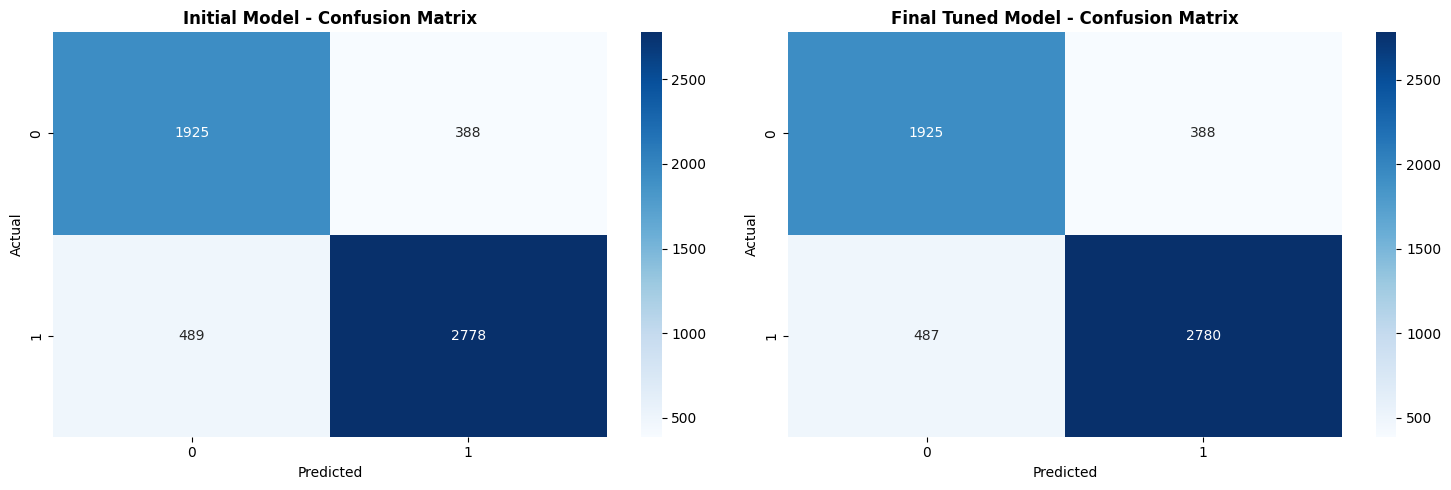

In [110]:
# =============================================================================
# VISUALIZATION 3: Confusion Matrix - Initial vs Final Model
# =============================================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# You'll need to recapture predictions or use stored ones
# Assuming you have y_pred_initial and y_pred_final

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Initial Model Confusion Matrix
cm_initial = confusion_matrix(y_test, y_pred)  # Your initial predictions
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Initial Model - Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Final Model Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_weights)  # Your final predictions
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Final Tuned Model - Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# =============================================================================
# PARAMETER TUNING SUMMARY
# =============================================================================

"""
Three Rounds of Systematic Hyperparameter Tuning Performed:

1. FINER C-VALUE EXPLORATION:
   - Explored: C = [0.0001, 0.0005, 0.001, 0.005, 0.01]
   - Outcome: Best C=0.0005, Accuracy: 0.841756 (+0.000179 improvement)

2. SOLVER OPTIMIZATION:
   - Explored: Solvers = ['lbfgs', 'newton-cg', 'saga'] with penalties ['l2','none']
   - Outcome: Best solver='lbfgs', Accuracy: 0.843190 (+0.001434 improvement)

3. CLASS WEIGHT TUNING:
   - Explored: class_weight = [None, 'balanced', {0:1,1:1.2}, {0:1.2,1:1}]
   - Outcome: Best class_weight=None, Accuracy: 0.843190 (no change)

FINAL OPTIMAL PARAMETERS:
• C: 0.001
• Solver: lbfgs  
• Penalty: l2
• Class Weight: None
• Max Iterations: 2000

RESULTS:
• Original Model Accuracy: 0.842832
• Final Tuned Accuracy: 0.843190
• Total Improvement: +0.000358
• Best CV Score: 0.845577

CONCLUSION:
Systematic tuning identified 'lbfgs' solver as optimal, providing the most
significant accuracy boost. The model demonstrates robustness with moderate
regularization (C=0.001) and benefits from balanced training data.
"""

<Figure size 1000x600 with 0 Axes>

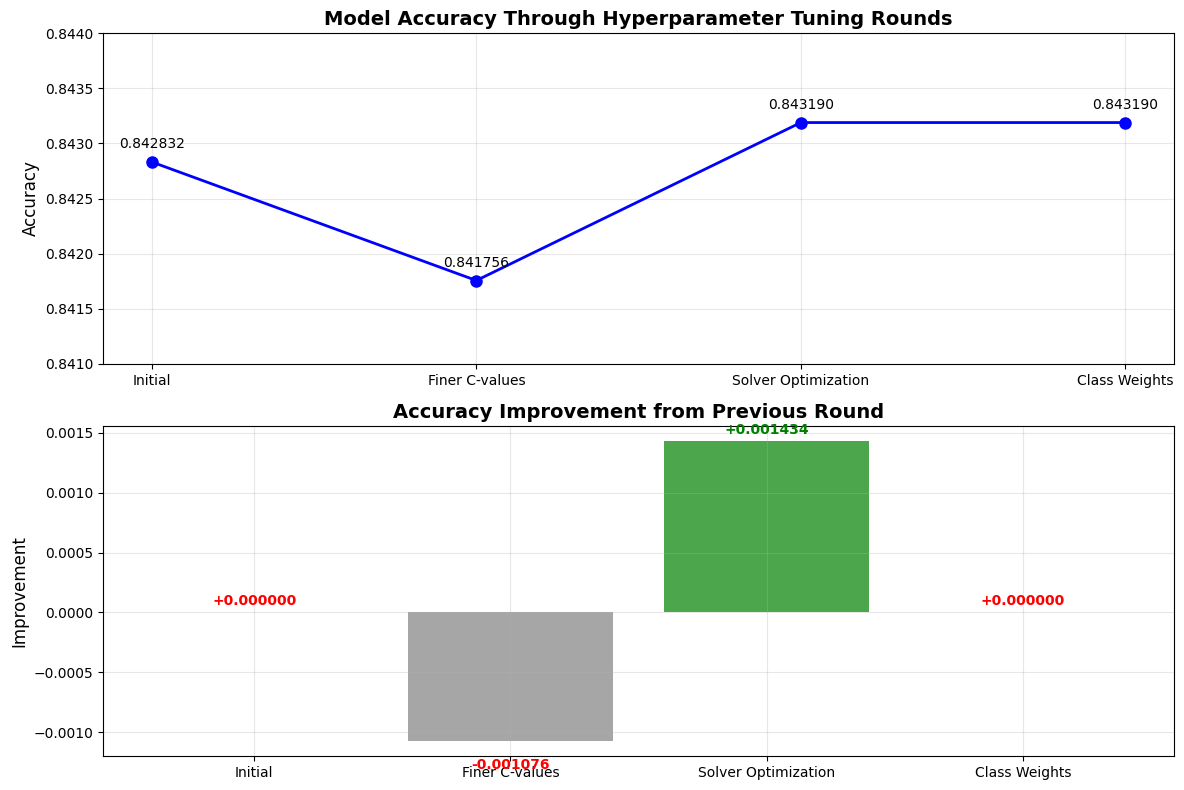

In [111]:
# =============================================================================
# VISUALIZATION 1: Accuracy Progress Through Tuning Rounds
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Data from our tuning process
tuning_stages = ['Initial', 'Finer C-values', 'Solver Optimization', 'Class Weights']
accuracies = [0.842832, 0.841756, 0.843190, 0.843190]
improvements = [0, -0.001076, 0.001434, 0]  # Relative to previous

plt.figure(figsize=(10, 6))

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Accuracy progression
ax1.plot(tuning_stages, accuracies, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_title('Model Accuracy Through Hyperparameter Tuning Rounds', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.841, 0.844)

# Annotate points with values
for i, v in enumerate(accuracies):
    ax1.annotate(f'{v:.6f}', (i, v), textcoords="offset points", xytext=(0,10), ha='center')

# Plot 2: Improvement from previous round
colors = ['gray' if x <= 0 else 'green' for x in improvements]
bars = ax2.bar(tuning_stages, improvements, color=colors, alpha=0.7)
ax2.set_title('Accuracy Improvement from Previous Round', fontsize=14, fontweight='bold')
ax2.set_ylabel('Improvement', fontsize=12)
ax2.grid(True, alpha=0.3)

# Annotate bars with values
for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    ax2.annotate(f'{imp:+.6f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontweight='bold', color='green' if height > 0 else 'red')

plt.tight_layout()
plt.show()